# ch254 — Central Limit Theorem

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. The Most Important Theorem in Applied Statistics

Let X₁, X₂, ..., Xₙ be **independent, identically distributed** (i.i.d.) random variables with mean μ and finite variance σ². Define the sample mean:
$$\bar{X}_n = \frac{X_1 + X_2 + \cdots + X_n}{n}$$

The **Central Limit Theorem** (CLT) states:
$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0, 1) \quad \text{as } n \to \infty$$

Equivalently: the sum Sₙ = X₁ + ... + Xₙ is approximately N(nμ, nσ²) for large n.

**What makes this remarkable**: the original distribution of X can be anything — uniform, Poisson, exponential, Bernoulli. As long as it has finite variance, the sample mean becomes normally distributed for large n.

*(Mean from ch249; variance and σ/√n scaling from ch250; normal distribution from ch253.)*

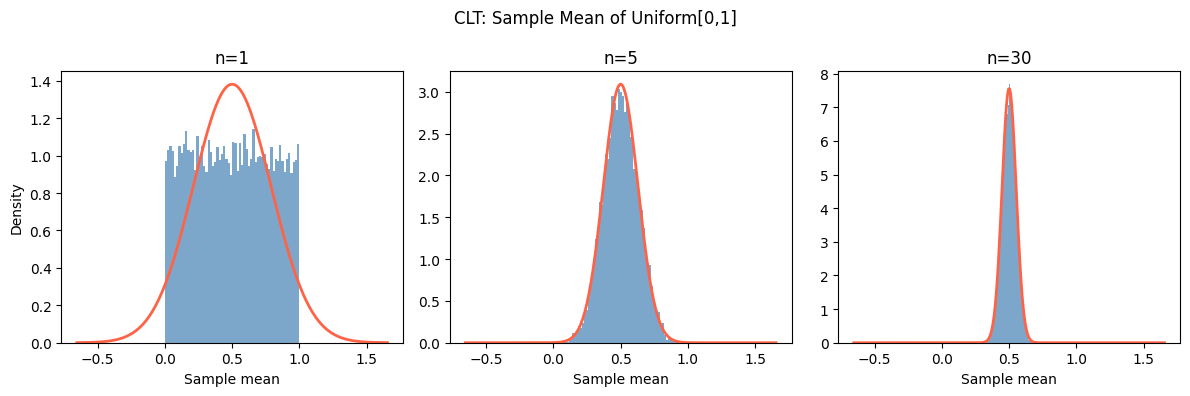

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def demonstrate_clt(distribution_name, sampler, mu, sigma, n_values, n_sims=10_000, seed=42):
    """
    Show the CLT in action for a given distribution.
    sampler(n_sims, n) returns n_sims samples of mean of n i.i.d. draws.
    """
    rng = np.random.default_rng(seed)
    
    fig, axes = plt.subplots(1, len(n_values), figsize=(4*len(n_values), 4))
    x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    
    for ax, n in zip(axes, n_values):
        # Simulate n_sims sample means, each from n draws
        samples = sampler(rng, n_sims, n)
        sigma_mean = sigma / np.sqrt(n)
        
        ax.hist(samples, bins=60, density=True, color='steelblue', alpha=0.7)
        ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma_mean), 'tomato', linewidth=2)
        ax.set_title(f'n={n}')
        ax.set_xlabel('Sample mean')
        if ax == axes[0]:
            ax.set_ylabel('Density')
    
    fig.suptitle(f'CLT: Sample Mean of {distribution_name}', fontsize=12)
    plt.tight_layout()
    plt.show()


# Test 1: Uniform[0,1] — mu=0.5, sigma=1/sqrt(12)
mu_u, sigma_u = 0.5, 1/np.sqrt(12)

def uniform_sampler(rng, n_sims, n):
    return rng.uniform(0, 1, size=(n_sims, n)).mean(axis=1)

demonstrate_clt('Uniform[0,1]', uniform_sampler, mu_u, sigma_u, [1, 5, 30])

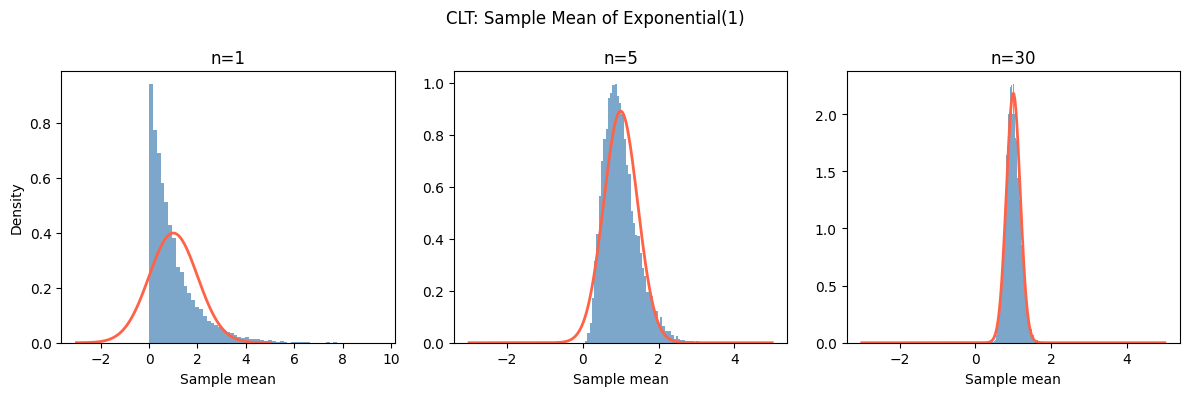

In [2]:
# Test 2: Exponential(rate=1) — mu=1, sigma=1
mu_e, sigma_e = 1.0, 1.0

def exp_sampler(rng, n_sims, n):
    return rng.exponential(scale=1.0, size=(n_sims, n)).mean(axis=1)

demonstrate_clt('Exponential(1)', exp_sampler, mu_e, sigma_e, [1, 5, 30])

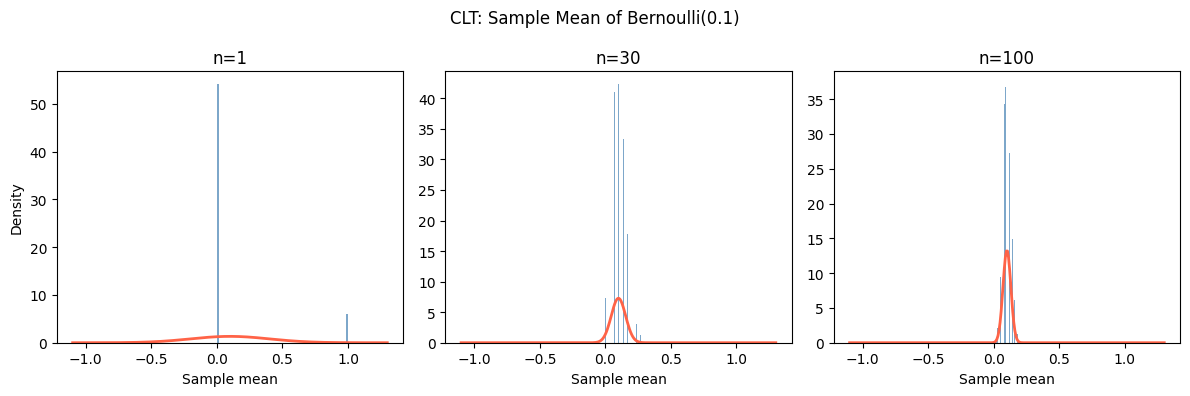

In [3]:
# Test 3: Bernoulli(0.1) — highly skewed — mu=0.1, sigma=sqrt(0.09)
p_bern = 0.1
mu_b, sigma_b = p_bern, np.sqrt(p_bern * (1 - p_bern))

def bern_sampler(rng, n_sims, n):
    return rng.binomial(1, p_bern, size=(n_sims, n)).mean(axis=1)

demonstrate_clt('Bernoulli(0.1)', bern_sampler, mu_b, sigma_b, [1, 30, 100])

## 2. The Standard Error

The CLT tells us the sample mean X̄ₙ has:
- Mean: μ
- Standard deviation: σ/√n — called the **standard error of the mean**

As n increases, the sample mean concentrates around μ at rate 1/√n. This is why collecting 4× more data halves the standard error (not quarters it).

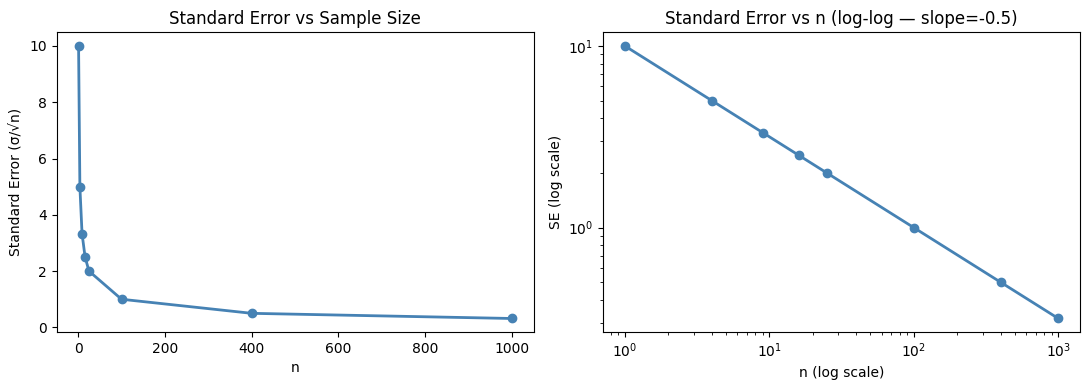

n → SE:
  n=    1: SE=10.0000
  n=    4: SE=5.0000
  n=    9: SE=3.3333
  n=   16: SE=2.5000
  n=   25: SE=2.0000
  n=  100: SE=1.0000
  n=  400: SE=0.5000
  n= 1000: SE=0.3162


In [4]:
# Standard error shrinks as 1/sqrt(n)
sigma = 10  # population std dev
n_values = np.array([1, 4, 9, 16, 25, 100, 400, 1000])
standard_errors = sigma / np.sqrt(n_values)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(n_values, standard_errors, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('n')
axes[0].set_ylabel('Standard Error (σ/√n)')
axes[0].set_title('Standard Error vs Sample Size')

axes[1].plot(n_values, standard_errors, 'o-', color='steelblue', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('n (log scale)')
axes[1].set_ylabel('SE (log scale)')
axes[1].set_title('Standard Error vs n (log-log — slope=-0.5)')

plt.tight_layout()
plt.show()

print("n → SE:")
for n, se in zip(n_values, standard_errors):
    print(f"  n={n:5d}: SE={se:.4f}")

## 3. When Does the CLT Apply?

| Condition | Requirement |
|-----------|-------------|
| Independence | Required |
| Finite variance | Required (distributions like Cauchy have no finite variance — CLT fails) |
| Sample size | n ≥ 30 is a common heuristic; more needed for skewed distributions |

The CLT does **not** require the original distribution to be normal. This is the key.

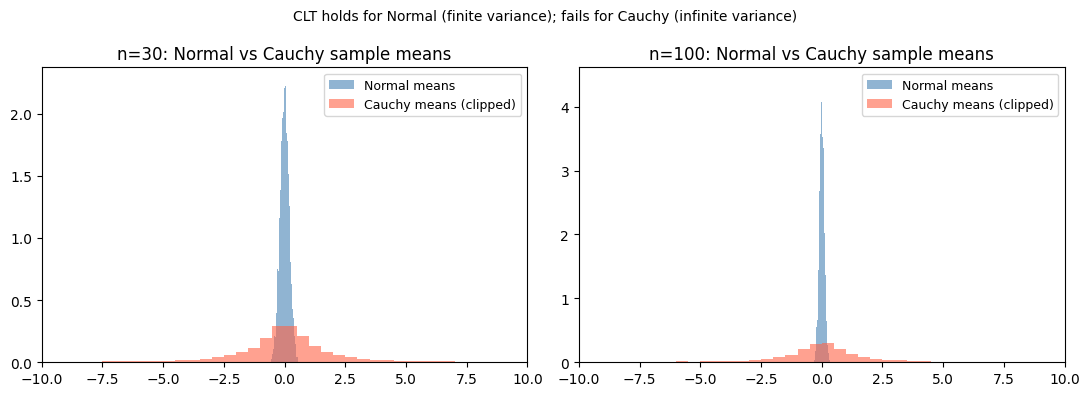

In [5]:
# Cauchy distribution: no finite mean or variance — CLT fails
rng = np.random.default_rng(seed=0)
n_sims = 10_000

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for n, ax in zip([30, 100], axes):
    # Normal (CLT applies): means converge nicely
    normal_means = rng.standard_normal(size=(n_sims, n)).mean(axis=1)
    # Cauchy (CLT does NOT apply): means do not converge
    cauchy_means = rng.standard_cauchy(size=(n_sims, n)).mean(axis=1)
    
    ax.hist(normal_means, bins=80, density=True, alpha=0.6, color='steelblue', label='Normal means')
    ax.hist(np.clip(cauchy_means, -20, 20), bins=80, density=True, alpha=0.6, color='tomato', label='Cauchy means (clipped)')
    ax.set_title(f'n={n}: Normal vs Cauchy sample means')
    ax.set_xlim(-10, 10)
    ax.legend(fontsize=9)

plt.suptitle('CLT holds for Normal (finite variance); fails for Cauchy (infinite variance)', fontsize=10)
plt.tight_layout()
plt.show()

## 4. CLT in Machine Learning

- **Mini-batch gradient descent**: gradients computed on mini-batches are noisy estimates of the full gradient. By CLT, larger batches produce gradient estimates that are more normally distributed around the true gradient.
- **Confidence intervals**: the formula X̄ ± z·σ/√n assumes the CLT to justify the normal approximation.
- **Model averaging**: averaging multiple model predictions (ensemble methods) reduces variance by factor n, standard error by √n — direct consequence of CLT.

---

## 5. Summary

- The CLT: the sample mean of n i.i.d. random variables with mean μ and variance σ² is approximately N(μ, σ²/n) for large n.
- This holds regardless of the original distribution, as long as variance is finite.
- Standard error = σ/√n: doubling sample size reduces SE by factor √2.
- The CLT explains why the normal distribution appears everywhere in statistics.

---

## 6. Forward References

The CLT directly produces confidence intervals (Part IX, ch280) and powers hypothesis testing (ch278). The Law of Large Numbers (ch255) is the partner theorem that addresses not the distribution of the sample mean, but its convergence to the true mean as n → ∞.